# 30회 기출 풀이


# 1. 혈압데이터(DBP) 회귀

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
import warnings

warnings.filterwarnings('ignore')

In [3]:
d1 = pd.read_csv('https://raw.githubusercontent.com/Datamanim/datarepo/main/adp/30/p1.csv')
d1.head()

,Age,Gender,BMI,DBP,FPG,Chol,Tri,HDL,LDL,ALT,CCR,FFPG
0,26,1,20.1,81,5.80,4.36,0.86,0.90,2.43,12.0,63.8,5.40
1,40,1,17.7,54,4.60,3.70,1.02,1.50,2.04,9.2,70.3,4.10
2,40,2,19.7,53,5.30,5.87,1.29,1.75,3.37,10.1,61.1,4.85
3,43,1,23.1,71,4.50,4.05,0.74,1.27,2.60,36.5,73.4,5.30
4,36,1,26.5,82,5.54,6.69,3.49,0.91,3.64,69.3,67.5,5.53


## 1-1 EDA 시행하라

In [4]:
d1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4303 entries, 0 to 4302
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Age     4303 non-null   int64  
 1   Gender  4303 non-null   int64  
 2   BMI     4303 non-null   float64
 3   DBP     4303 non-null   int64  
 4   FPG     4303 non-null   float64
 5   Chol    4302 non-null   float64
 6   Tri     4303 non-null   float64
 7   HDL     4303 non-null   float64
 8   LDL     4303 non-null   float64
 9   ALT     4303 non-null   float64
 10  CCR     4303 non-null   float64
 11  FFPG    4303 non-null   float64
dtypes: float64(9), int64(3)
memory usage: 403.5 KB


In [11]:
d1.Gender.unique()
d1['Gender'] = d1['Gender'].astype('object')

11개의 수치형 변수로 구성되어 있으며, 결측치가 포함된 컬럼이 식별된다.   
gender는 바이너리 값을 가진 카테고리 변수이다. 

In [12]:
d1.isna().sum()

Age       0
Gender    0
BMI       0
DBP       0
FPG       0
Chol      1
Tri       0
HDL       0
LDL       0
ALT       0
CCR       0
FFPG      0
dtype: int64

콜레스테롤 컬럼에서 결측치가 하나 존재하는 것을 확인할 수 있다.   
보간 또는 삭제를 할 수 있지만, 결측치가 1개로 아주 작은 비율이기 때문에 삭제한다.  

In [15]:
print('<연속형 변수>')
display(d1.describe().T)

print('<명목형 변수>')
display(d1.describe(include='object'))

<연속형 변수>


,count,mean,std,min,25%,50%,75%,max
Age,4303.0,48.085057,14.686155,22.000000,35.00,46.00,59.00,93.000000
BMI,4303.0,24.123923,3.397294,15.600000,21.70,24.00,26.30,45.800000
DBP,4303.0,76.360446,11.004056,45.000000,69.00,76.00,83.00,134.000000
FPG,4303.0,5.226368,0.781089,1.780000,4.70,5.14,5.70,6.990000
Chol,4302.0,4.860732,0.925484,1.650000,4.20,4.79,5.43,11.650000
Tri,4303.0,1.588476,1.260003,0.000000,0.86,1.28,1.94,32.640000
HDL,4303.0,1.666765,1.079377,0.000000,1.13,1.34,1.61,4.860753
LDL,4303.0,2.976220,0.892196,0.540000,2.35,2.82,3.42,6.270000
ALT,4303.0,26.754810,22.279922,4.500000,14.30,20.50,31.05,436.200000
CCR,4303.0,71.557080,16.937394,4.860753,60.00,72.00,82.30,307.000000


<명목형 변수>


,Gender
count,4303
unique,2
top,1
freq,2790


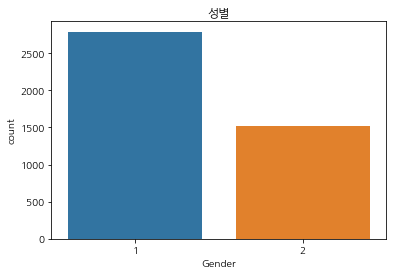

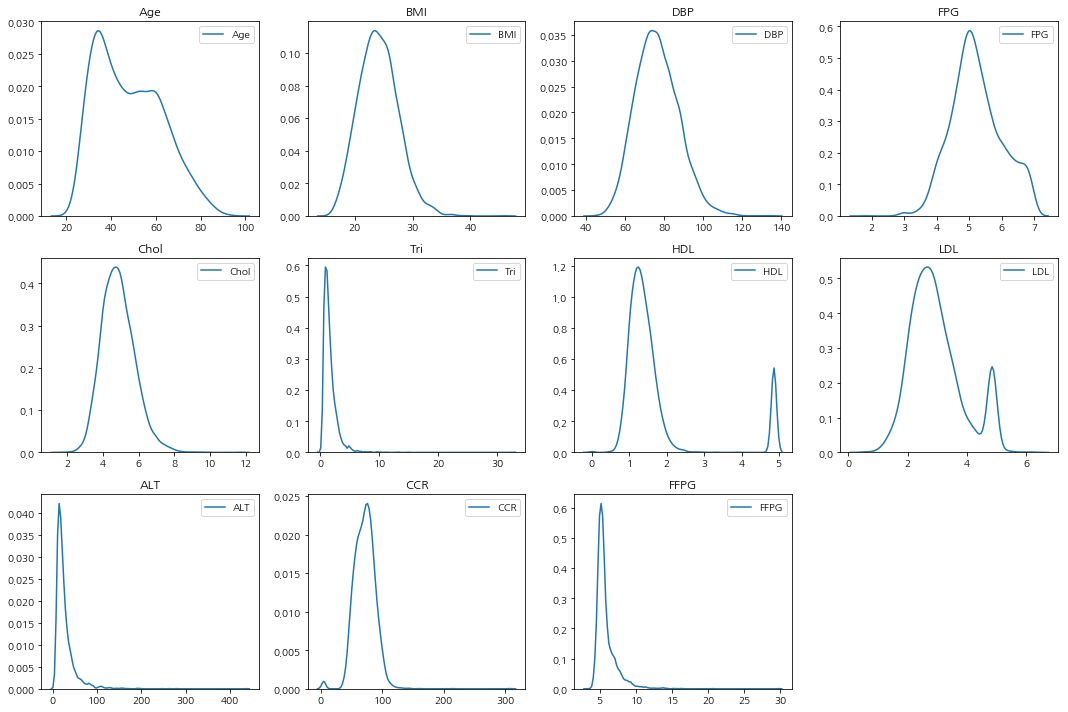

In [22]:
num_cols = d1.select_dtypes('number').columns

sns.countplot(d1['Gender'])
plt.title('성별')
plt.show()

fig, axes = plt.subplots(3, 4, figsize=(15, 10))

for col, ax in zip(num_cols, axes.flatten()):
    sns.kdeplot(d1[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
axes[2, 3].remove()
plt.show()

- 성별은 남성이 여성에 비율이 높음(64:36)
- bmi, dbp, chol, tri, alt, ccr, ffpg는 오른쪽으로 긴꼬리를 가진 양의왜도 분포를 보이고 있음  
  분포의 비대칭성 완화를 위해 log, box-cox, yeo-johnson, 제곱근, 역수변환을 고려할 수 있음
- 특히 tri, alt, ffpg는 특정영역에 값이 집중되는 분포를 보임
- hdl은 1~2, 4.6~5 영역에 쌍봉분포를 보임

## 1-2 데이터 전처리가 필요하다면 수행하고 이유를 작성하라

In [24]:
d1 = d1.dropna()
d1.isna().sum()

Age       0
Gender    0
BMI       0
DBP       0
FPG       0
Chol      0
Tri       0
HDL       0
LDL       0
ALT       0
CCR       0
FFPG      0
dtype: int64

콜레스테롤 컬럼에 결측치가 1개 존재했기 때문에 삭제처리를 해 준다.  
데이터에 비해 결측비율이 아주 낮으며, 데이터에 대한 지식이 없는 상태에서 보간을 한다면 데이터의 왜곡을 발생시킬 수 있기 때문이다.   
다음으로 전체 데이터의 이상치 여부를 확인한다.(연속형 변수만)

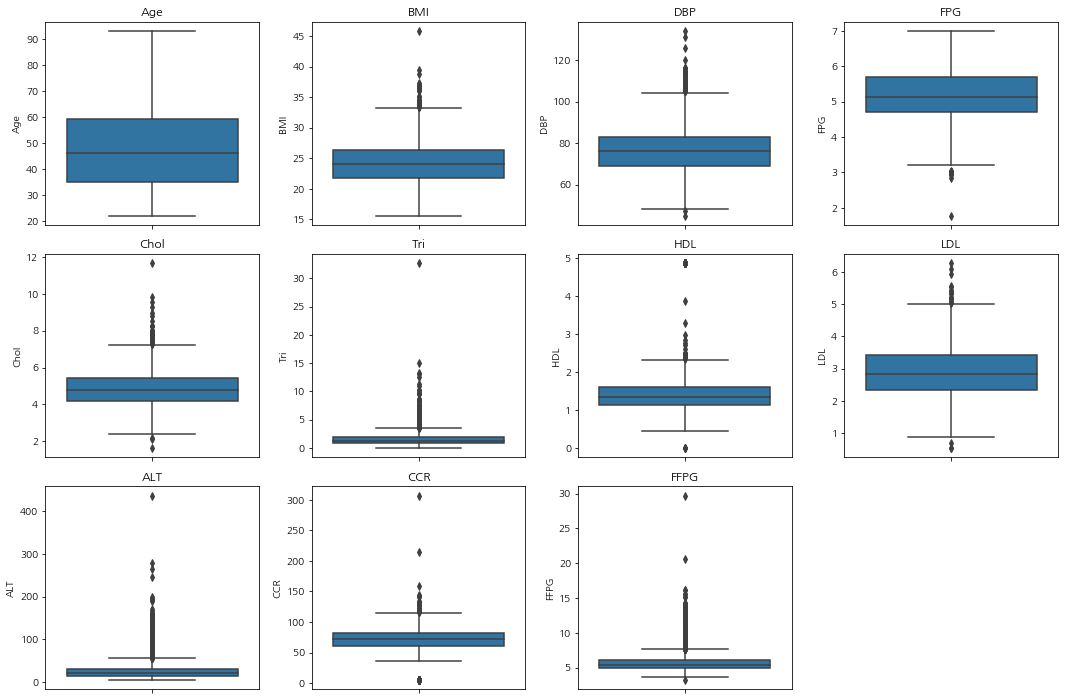

In [25]:
fig, axes = plt.subplots(3, 4, figsize=(15, 10))

for col, ax in zip(num_cols, axes.flatten()):
    sns.boxplot(y=d1[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
axes[2, 3].remove()
plt.show()

boxplot으로 확인했을 때 alt등 일부 데이터에 대해서 outerlier로 보이는 값들이 식별된다.    
iqr 기준으로 상/하단 범위를 벗어나는 각 컬럼의 데이터의 개수를 확인한다. 

In [31]:
ds = d1[num_cols].describe().T

q1 = ds['25%']
q3 = ds['75%']
iqr = q3-q1
top = q3 + (1.5*iqr)
down = q1 - (1.5*iqr)

print("<<IQR 기준 상하단 이상치 수>>")
for idx in top.index:
    cnt = len(d1[(d1[idx] > top[idx]) | (d1[idx] < down[idx])])
    print(f"- {idx} ({down[idx]:.3f} ~ {top[idx]:.3f}): {cnt}")

<<IQR 기준 상하단 이상치 수>>
- Age (-1.000 ~ 95.000): 0
- BMI (14.800 ~ 33.200): 41
- DBP (48.000 ~ 104.000): 53
- FPG (3.200 ~ 7.200): 17
- Chol (2.355 ~ 7.275): 63
- Tri (-0.760 ~ 3.560): 215
- HDL (0.410 ~ 2.330): 436
- LDL (0.745 ~ 5.025): 19
- ALT (-10.863 ~ 56.238): 299
- CCR (26.550 ~ 115.750): 56
- FFPG (3.220 ~ 7.700): 349


IQR 기준으로 10개의 컬럼에서 이상치가 식별되었다.   
하지만 해당 데이터는 생체 데이터이며, 해당 데이터에 대한 지식이 없기 때문에 이상치 진위여부를 확인할 수 없다.  
또한 상하단 극단값들이 분류, 회귀에서 중요한 패턴 정보를 포함하고 있을 가능성이 있으며,  
무분별한 제거 시 모델의 일반화 성능이 저하될 위험이 있다.  
따라서 도메인 전문가의 검토 없이는 이상치를 제거하지 않고 원본 데이터를 유지하여 분석을 진행하기로 결정하였다. 

## 1-3 train test set을 DBP 컬럼 기준으로 7:3 비율로 나누고, 잘나뉘었는지 통계적으로 나타내라

In [32]:
from sklearn.model_selection import train_test_split

Y = d1['DBP']
X = d1.drop('DBP', axis=1)

train_X, test_X, train_Y, test_Y = train_test_split(X, Y, test_size=0.3, random_state=42)

print(train_X.shape, test_X.shape)

(3011, 11) (1291, 11)


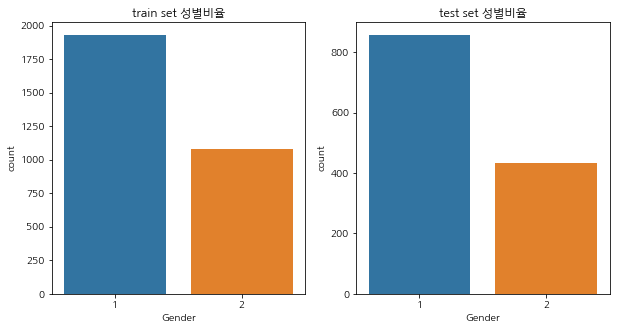

In [41]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

sns.countplot(train_X['Gender'], ax=ax[0])
sns.countplot(test_X['Gender'], ax=ax[1])
ax[0].set_title('train set 성별비율')
ax[1].set_title('test set 성별비율')
plt.show()

명목형 변수의 경우 두 데이터셋에서 동일한 비율을 보이는 것을 확인할 수 있다.

데이터를 DBP 컬럼을 종속변수로, 나머지 변수를 독립변수로 하여 7:3 비율로 train/test set 분할하였다. 다음으로 두 데이터셋의 분포가 동일한지 확인하기 위해 K-S 테스트를 수행한다. 

K-S(Kolmogorov–Smirnov 2-sample) 테스트는 두 집단의 분포(형태, 위치, 스케일)를 검정할 수 있는 대표적인 비모수 기법이다.

- 귀무가설: 두 데이터셋은 동일한 분포를 가진다. 
- 대립가설: 두 데이터셋은 동일한 분포를 따르지 않는다. 

In [33]:
from scipy.stats import ks_2samp

for col in train_X.columns:
    stat, p = ks_2samp(train_X[col], test_X[col])
    print(f"{col} 통계량: {stat:.3f} / p-value: {p:.3f} / 귀무가설", "기각" if p < 0.05 else "기각x")

Age 통계량: 0.023 / p-value: 0.697 / 귀무가설 기각x
Gender 통계량: 0.023 / p-value: 0.700 / 귀무가설 기각x
BMI 통계량: 0.026 / p-value: 0.579 / 귀무가설 기각x
FPG 통계량: 0.035 / p-value: 0.204 / 귀무가설 기각x
Chol 통계량: 0.018 / p-value: 0.933 / 귀무가설 기각x
Tri 통계량: 0.020 / p-value: 0.836 / 귀무가설 기각x
HDL 통계량: 0.026 / p-value: 0.570 / 귀무가설 기각x
LDL 통계량: 0.037 / p-value: 0.174 / 귀무가설 기각x
ALT 통계량: 0.015 / p-value: 0.981 / 귀무가설 기각x
CCR 통계량: 0.029 / p-value: 0.408 / 귀무가설 기각x
FFPG 통계량: 0.030 / p-value: 0.389 / 귀무가설 기각x


K-S 테스트 결과 모든 컬럼의 p-value가 0.05보다 크므로 귀무가설을 기각할 수 없었다.  
따라서 두 데이터셋은 동일한 분포를 가진다고 할 수 있으며,  
train/test set은 동일한 분포로 잘 나누어졌다. 

## 1-4 독립변수의 차원축소 필요성을 논하고, 필요에 따라 차원을 축소해라. 불필요하다면 그 근거를 논해라.

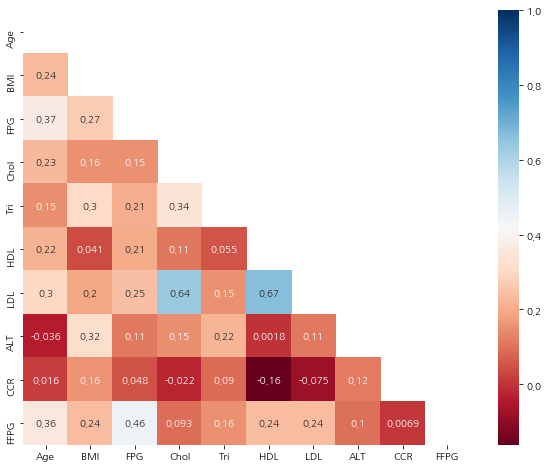

In [36]:
plt.figure(figsize=(10, 8))
corr = train_X.corr()
mask = np.triu(np.ones_like(corr, dtype='bool'))
sns.heatmap(corr, mask=mask, annot=True, cmap='RdBu')
plt.show()

우선 train set 독립변수 기준으로 수치형변수의 1:1 선형 상관관계를 확인하기 위해 피어슨 상관관계 분석을 수행한다.  
HDL-LDL 0.67(양의 상관관계)를 제외하고는 뚜렷한 상관성이 관찰되지는 않는다.   
다음으로 vif를 통해 다중공선성을 진단한다.

In [40]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

num_cols = train_X.select_dtypes('number').columns
vif = pd.DataFrame()
vif['name'] = num_cols
vif['vif'] = [variance_inflation_factor(train_X[num_cols].values, i) for i in range (len(num_cols))]

display(vif)

,name,vif
0,Age,15.742528
1,BMI,50.795775
2,FPG,54.537026
3,Chol,60.028306
4,Tri,2.953138
5,HDL,8.837626
6,LDL,51.811034
7,ALT,2.712987
8,CCR,17.861943
9,FFPG,22.707544


VIF는 다중공성성을 진단하기 위한 편리한 척도로, 일반적으로 10이상이면   
다른 변수들의 선형조합으로 충분히 설명될 정도의 다중공선성이 있다고 본다.   
10개의 변수 중 7개의 변수에서 굉장히 높은 다중공선성이 관찰된다.  

따라서 다중공선성 문제를 완화하기 위해 차원축소를 실시한다.  
여러 차원축소 방법 중 SVD를 이용한 비지도학습 기법인 PCA를 사용한다.  
* PCA: 고차원 데이터의 분산이 큰 방향으로 축을 찾아 데이터를 저차원으로 투영,   원본특성 간 상관관계를 이용해 서로 직교하는 주성분을 만들고, 분산이 큰 순서대로 표현해 정보손실을 최소화



,고윳값,분산설명력,누적분산설명력
0,92.810039,0.286075,0.286075
1,68.296439,0.154912,0.440987
2,61.707733,0.126464,0.567451
3,52.561249,0.091753,0.659204
4,51.032231,0.086492,0.745697
5,45.334162,0.068256,0.813953
6,44.700877,0.066362,0.880315
7,40.646339,0.054870,0.935184
8,40.105800,0.053420,0.988604
9,18.523512,0.011396,1.000000


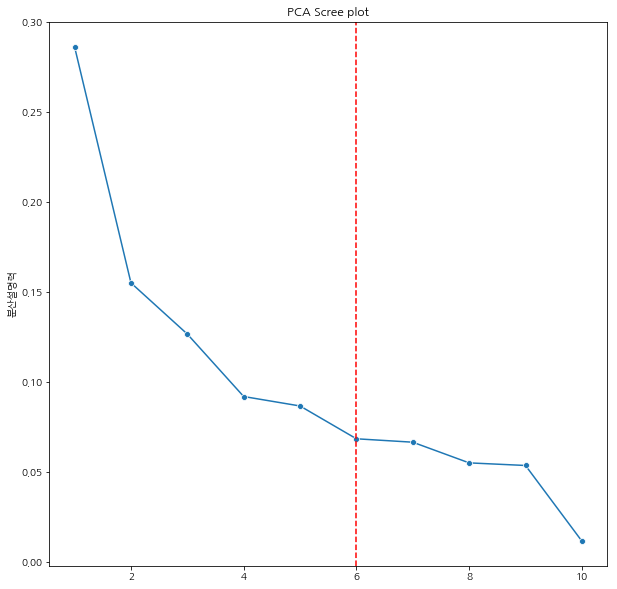

In [67]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

#스케일링
sc = StandardScaler() 
train_X_n = sc.fit_transform(train_X[num_cols])
test_X_n = sc.transform(test_X[num_cols])

#pca로 주성분 분산설명력 확인 및 주성분 개수 찾기
pca = PCA()
train = pca.fit_transform(train_X_n)

rs = pd.DataFrame({"고윳값": pca.singular_values_, 
                  "분산설명력": pca.explained_variance_ratio_, 
                  "누적분산설명력": np.cumsum(pca.explained_variance_ratio_)})
display(rs)

plt.figure(figsize=(10, 10))
sns.lineplot(data=rs, x=rs.index+1, y='분산설명력', marker='o')
plt.title('PCA Scree plot')
plt.axvline(x=6, color='r', ls='--')
plt.show()

pca = PCA(n_components=6)
train_X_n = pca.fit_transform(train_X_n)
test_X_n = pca.fit_transform(test_X_n)

PCA 의 주성분축의 개수를 확인하기 위해 분산설명력을 이용하여 Scree plot을 그린다. 엘보지점이 명확하지는 않지만 누적분산설명력이 80%(원본데이터 분산의 80%를 설명)이 넘는 지점인 6을 선택하여 차원축소를 진행한다. 새롭게 생성된 주성분 축 간에는 직교하므로 vif가 1이 되어 다중공선성이 제거된다. 

## 1-5 작업 후 데이터가 회귀분석의 기본 가정을 따르는지 설명하시오.

훈련 데이터를 이용하여 회귀분석을 실시한다.  
회귀분석은 기본가정을 만족하여야 하므로 모델 적합 후 잔차검정을 수행한다.   
<기본가정>
- 선형성: 독립변수와 종속변수 간에는 선형관계 있어야 함
- 독립성: 오차들은 서로 독립적이어야 함
- 등분산성: 모든 수준의 독립변수에서 오차의 분산이 일정해야 함
- 정규성: 오차항은 정규분포를 따라야 함

잔차검정은 유의수준 5% 하에서 다음과 같이 수행한다. 
- 선형성: 잔차-예측값 산점도 확인(선형패턴여부)
- 독립성: 더빈-왓슨 통계량
- 등분산성: Breusch-Pagan 검정
- 정규성: Shapiro-Wilk test

In [68]:
train_X_n = pd.DataFrame(train_X_n, columns=['comb'+str(i) for i in range(1, 7)])
test_X_n = pd.DataFrame(test_X_n, columns=['comb'+str(i) for i in range(1, 7)])
train_X_n = pd.concat([train_X_n.reset_index(drop=True), train_X['Gender'].reset_index(drop=True)], axis=1)
test_X_n = pd.concat([test_X_n.reset_index(drop=True), test_X['Gender'].reset_index(drop=True)], axis=1)


import statsmodels.api as sm
import statsmodels.formula.api as smf

train = pd.concat([train_Y.reset_index(drop=True), train_X_n], axis=1)

model = smf.ols("DBP~C(Gender)+comb1+comb2+comb3+comb4+comb5+comb6", 
               data=train).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    DBP   R-squared:                       0.140
Model:                            OLS   Adj. R-squared:                  0.138
Method:                 Least Squares   F-statistic:                     69.90
Date:                Thu, 04 Sep 2025   Prob (F-statistic):           7.19e-94
Time:                        14:41:20   Log-Likelihood:                -11289.
No. Observations:                3011   AIC:                         2.259e+04
Df Residuals:                    3003   BIC:                         2.264e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         77.2889      0.266    290.926      0.000      76.768      77.810
C(Gender)[T.2]    -2.6980      0.524     -5.145      0.000      -3.726      -1.670
comb1              1.8595      0.112     16.618      0.000       1.640       2.079
comb2              1.2165      0.178      6.841      0.000       0.868       1.565
comb3             -0.3240      0.167     -1.942      0.052      -0.651       0.003
comb4             -0.2932      0.196     -1.497      0.135      -0.677       0.091
comb5              0.3169      0.236      1.344      0.179      -0.145       0.779
comb6             -1.2484      0.230     -5.438      0.000      -1.698      -0.798
==============================================================================
Omnibus:                      117.837   Durbin-Watson:                   2.019
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              157.036
Skew:                           0.404   Prob(JB):                     7.94e-35
Kurtosis:                       3.774   Cond. No.                         5.28
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

기본적인 선형 회귀모델을 적합하였다. 모델의 설명력은 0.14로 낮으며,  
comb3, 4, 5는 p-value가 높아 귀무가설을 기각할 수 없다.  
(해당 feature의 계수는 0이다.)

회귀모델의 기본가정을 만족해야 위 해석이 신뢰성을 가지므로 잔차를 이용하여  
선형성, 독립성, 등분산성, 정규성 검정을 수행한다. 

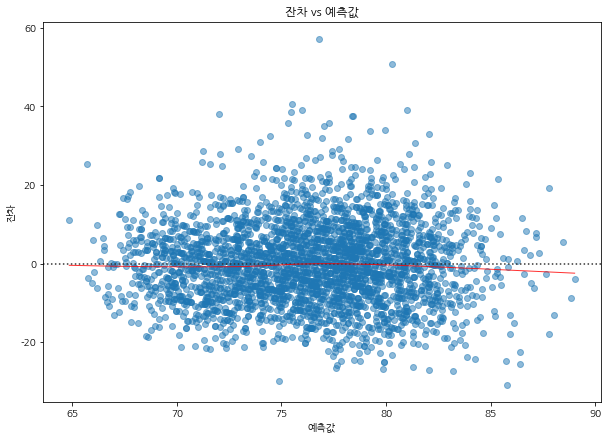

- BP LM 통계량: 61.147, p-value: 0.000
- 샤피로 검정 통계량: 0.991, p-value: 0.000


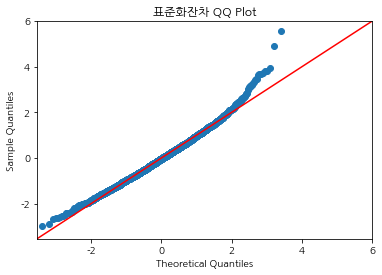

- 더빈왓슨검정 통계량: 2.019


In [73]:
resid = model.resid
# 선형성 검정: 잔차-예측값 검정
pred_y = model.fittedvalues

plt.figure(figsize=(10, 7))
sns.residplot(x=pred_y, y='DBP', data=train, lowess=True, 
             scatter_kws={'alpha':0.5}, 
             line_kws={'color':'r', 'lw':1, 'alpha':0.8})
plt.title('잔차 vs 예측값')
plt.xlabel('예측값')
plt.ylabel('잔차')
plt.show()

# 등분산성 검정: : Breusch-Pagan
from statsmodels.stats.diagnostic import het_breuschpagan
bp_test = het_breuschpagan(model.resid, model.model.exog)
# 반환값: (Lagrange multiplier, p-value, f-value, f p-value)
lm_stat, lm_pvalue, f_stat, f_pvalue = bp_test
print(f"- BP LM 통계량: {lm_stat:.3f}, p-value: {lm_pvalue:.3f}")

# 정규성 검정: shapiro wilk 검정
from scipy.stats import shapiro

stat, p = shapiro(resid)
print(f"- 샤피로 검정 통계량: {stat:.3f}, p-value: {p:.3f}")
qq = sm.ProbPlot(model.get_influence().resid_studentized_internal, fit=True)
fig = qq.qqplot(line='45', color='black')
plt.title('표준화잔차 QQ Plot')
plt.show()

# 독립성 검정: dubin watshon 검정
from statsmodels.stats.stattools import durbin_watson

dw_stat = durbin_watson(resid)
print(f"- 더빈왓슨검정 통계량: {dw_stat:.3f}")

<잔차검정 결과>  
- 선형성: 만족
  * 잔차-예측값 산점도 상 잔차가 0을 중심으로 무작위로 고르게 분포하며,   
    lowess 곡선이 직선에 가까운 형태를 보임
- 등분산성: 만족
  * Breusch-Pagan 검정결과, 유의수준 5% 하에서 귀무가설 기각으로 등분산성 불만족이나, 잔차-예측값 산점도 상 분산의 증감, 패턴이 관찰되지 않으므로 등분산성 만족
- 정규성: 만족
  * shapiro 검정결과는 귀무가설 기각으로 정규성을 만족하지 않지만, qq-plot 상 상단 일부 값을 제외하고는 직선 상에 위치하므로 정규성을 만족한다고 봄
  
- 독립성: 만족
  * 더빈왓슨 검정결과 2에 아주 가까운 값을 보임

## 1-6 회귀분석 알고리즘 3개를 선택하고 선정이유와 장단점을 비교하라.

1. Linear Regression: 가장 기본적인 선형회귀 모델로, 다른 모델과의 비교를 위해 사용한다. 간단하고 빠르며, 계수해석이 용이하고, 구현이 쉽다는 장점이 있으나, 이상치와 다중공선성에 민감하고 예측 성능이 낮을 수 있다는 단점이 있음

2. 릿지회귀: L2 정규화로 변수 간 다중공선성이 강해 완화가 필요한 경우 적합한 모델로 예측안정성 향상 효과가 있다, 모든 변수를 유지하면서 과적합을 억제하는 장점이 있으나, 계수해석이 어렵고 하이퍼파라미터(규제강도) 설정이 어려움

3. 랜덤 포레스트 회귀: 트리, 배깅기반 회귀모델로, 비선형/상호관계 자동학습이 가능하며, 이상치/다중공선성/스케일 영향이 적고, 과적합에 강한 모델이다.  단점으로 해석이 어려우며, 고차원일 시 시간과 비용이 많이 소요된다. 

해당 데이터는 다중공선성이 있는 데이터이며(원본), EDA 시 이상치로 보이는 값들이 관찰되었으므로 릿지, 랜덤포레스트 회귀를 선정하고 비교군으로 선형 회귀를 사용한다. 

## 1-7 1-3에서 구분한 데이터를 기준으로, 3개의 회귀분석 모델링을 진행하고 평가지표 rmse로 가장 최적화된 알고리즘을 선정해라.

In [90]:
from sklearn.compose import make_column_transformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

n_cols = train_X.select_dtypes('number').columns
c_cols = train_X.select_dtypes(exclude='number').columns

#전처리 컬럼 트랜스포머: 스케일링, pca, onehot 인코딩
pre_processor = make_column_transformer(
    (Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=6))]), n_cols), 
    (Pipeline([('onehot', OneHotEncoder())]), c_cols), 
    remainder='passthrough'
)

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

#기본 모델들 적합
lr = Pipeline([
    ('preprocess', pre_processor), 
    ('regressor', LinearRegression())
])
rd = Pipeline([
    ('preprocess', pre_processor), 
    ('regressor', Ridge(random_state=42))
])
rf = Pipeline([
    ('preprocess', pre_processor), 
    ('regressor', RandomForestRegressor(random_state=42))
])

model_list = [('선형회귀', lr), ('릿지회귀', rd), ('랜덤포레스트회귀', rf)] #모델리스트
dt_list = [('train', train_X, train_Y), ('test', test_X, test_Y)]#데이터리스트

#결과 데이터프레임화
rs = pd.DataFrame(columns=['모델명', '데이터명', 'rmse'])

#모델학습 및 결과
for m_name, model in model_list:
    model.fit(train_X, train_Y)
    for d_name, x, y in dt_list:
        pred = model.predict(x)
        rmse = np.sqrt(mean_squared_error(y, pred))
        rs.loc[len(rs)] = [m_name, d_name, rmse]
display(rs)

,모델명,데이터명,rmse
0,선형회귀,train,10.280907
1,선형회귀,test,9.923874
2,릿지회귀,train,10.280907
3,릿지회귀,test,9.923947
4,랜덤포레스트회귀,train,4.014988
5,랜덤포레스트회귀,test,10.278278


test set 기준으로 평가했을 시 선형회귀와 릿지회귀의 rmse 점수가 동일하였다.   
L2 정규화로 변수 간 다중공선성이 강해 완화가 필요한 경우 적합한 모델인 릿지회귀를 선택한다. 

## 1-8 1-7에서 가장 성능 좋은 알고리즘을 이용하여 K-Fold 교차검증 수행하라.

In [93]:
from sklearn.model_selection import GridSearchCV

rd_param = {
    # L2 페널티 강도: 10^(-4) ~ 10^4 구간을 로그 스케일로 탐색
    'regressor__alpha': [1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100, 1e3, 1e4],
    # 절편 사용 여부
    'regressor__fit_intercept': [True, False],
    # 표준화(normalize) 옵션 (sklearn 1.0 이하에서 유효, 이후는 Pipeline 권장)
    'regressor__normalize': [True, False],
    # solver별 성능 차이 탐색
    'regressor__solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sag']
}

rd_sh = GridSearchCV(
    estimator = rd,
    param_grid = rd_param,
    scoring='neg_root_mean_squared_error',
    cv=5
)
#모델학습 및 결과
rd_sh.fit(train_X, train_Y)

print(f"Best Params: {rd_sh.best_params_}")
print(f"Best Score: {-1*rd_sh.best_score_:.2f}")

for d_name, x, y in dt_list:
    pred = model.predict(x)
    rmse = np.sqrt(mean_squared_error(y, pred))
    rs.loc[len(rs)] = ['릿지교차검정', d_name, rmse]
display(rs)

Best Params: {'regressor__alpha': 0.1, 'regressor__fit_intercept': True, 'regressor__normalize': True, 'regressor__solver': 'auto'}
Best Score: 10.32


,모델명,데이터명,rmse
0,선형회귀,train,10.280907
1,선형회귀,test,9.923874
2,릿지회귀,train,10.280907
3,릿지회귀,test,9.923947
4,랜덤포레스트회귀,train,4.014988
5,랜덤포레스트회귀,test,10.278278
6,릿지교차검정,train,4.014988
7,릿지교차검정,test,10.278278
8,릿지교차검정,train,4.014988
9,릿지교차검정,test,10.278278


5-fold vaildation, 그리드 서치 결과, train set의 학습성능은 좋아졌으나  
test set의 성능은 낮아졌으며 일반화 성능이 이전보다 하락하였다.  
보다 최적화된 릿지모델의  파라미터 계수 조정이 필요하다. 

# 2. 피해자 신체 상해정도 분류
데이터 설명 : 자전거사고 다발지역 개별사고 정보

대상사고 : 해당 1년간 발생한 가해 또는 피해차종이 자전거인 교통사고

다발지역 선정조건 : 반경 300m 내 대상사고 4건이상 발생지역

종속 변수 : 피해자신체상해정도

In [ ]:
d2 = pd.read_csv('https://raw.githubusercontent.com/Datamanim/datarepo/main/adp/30/p2_v2.csv')
d2.head()

,사고년도,가해자성별,가해자연령,가해차종,가해자신체상해정도,피해자성별,피해자연령,피해차종,피해자신체상해정도,사고유형,가해자법규위반,기상상태,시각,사건번호
0,2015,남,46세,승합차,상해없음,여,64세,자전거,경상,차대차 - 기타,안전운전불이행,맑음,2015-07-03_10시,ID_796
1,2019,남,53세,승용차,상해없음,여,57세,자전거,경상,차대차 - 후진중충돌,안전운전불이행,맑음,2019-10-12_10시,ID_6697
2,2015,남,39세,승용차,상해없음,남,63세,자전거,중상,차대차 - 기타,기타,맑음,2015-03-23_20시,ID_919
3,2016,남,12세,자전거,상해없음,남,52세,보행자,경상,차대사람 - 길가장자리구역통행중,안전운전불이행,맑음,2016-04-10_15시,ID_2512
4,2015,남,54세,승용차,상해없음,남,63세,자전거,중상,차대차 - 기타,안전운전불이행,맑음,2015-08-04_6시,ID_75


## 2-1 발생시각을 통해 평일인지 주말인지 구분하는 '주말여부' 범주형 변수를 추가하고, 데이터 분포를 확인하라.

## 2-2 '피해자신체상해정도'에 따라 각 독립변수들이 유의한지 통계적으로 검정하라.

## 2-3 2-2에서 유의한 변수들만을 가지고 '피해자신체상해정도'를 기준으로 SMOTE 오버샘플링을 수행해라. 샘플링 데이터와 기존 데이터를 합친 전체 데이터에 대해 범주형 변수는 변수별 빈도를 나타내고, 연속형이면 평균을 나타내라.

## 2-4 2-3의 데이터를 가지고 '피해자신체상해정도'를 종속변수로 하여 로지스틱 회귀분석, XGB 분류분석 모델을 만들고 성능 비교하여 영향력 있는 변수를 확인하라.

# 통계

## 3. 선형계획법
3개의 공장에서 생산한 제품을 3지역으로 가능한 조건에 맞게 최대로 배송한다. 각 공장과 각 지역 사이 1개 제품 배송 비용이 아래와 같을 때, 최소 배송 비용은 얼마인가?
![image.png](attachment:0615c061-e0b9-4488-a1fc-f137ee12bdef.png)

In [ ]:
fct= ['A','B','C'] # 공장
reg= ['reg1','reg2','reg3'] # 지역
sup={'A':75,'B':55,'C':60} #총공급량
dem={'1':80,'2':50,'3':60} #총수요량
cost={('A','reg1'):20,('A','reg2'):5,('A','reg3'):35,
      ('B','reg1'):15,('B','reg2'):2,('B','reg3'):25,
      ('C','reg1'):3, ('C','reg2'):14,('C','reg3'):17}
import pandas as pd
import numpy as np
d3 = pd.Series(cost).unstack().reindex(index=fct, columns=reg)
d3

,reg1,reg2,reg3
A,20,5,35
B,15,2,25
C,3,14,17


## 4. 범주-범주 통계검정

데이터 설명 : 3개 연령층 (청년 장년 노년)의 A 헤드셋의 선호도 (1,2,3/ 범주형) 설문조사

In [ ]:
d4= pd.read_csv('https://raw.githubusercontent.com/Datamanim/datarepo/main/adp/30/p6.csv')
d4.head()

,나이,선호도
0,청년,2
1,장년,2
2,청년,2
3,청년,1
4,장년,1


### 4-1 연령대별 헤드셋 선호도에 차이가 있는지 검정하기 위한 귀무가설과 연구가설을 설정해라.

### 4-2 유의수준 하에서 통계검정해라.

### 5-1 아이를 6명 가진 가정이 5 가족이고, 아들/딸을 출생할 확률은 0.5이다. 딸이 4명 이상인 가구가 3가족 이상일 확률을 구하라.

### 5-2 5가족 중 몇 가족이 4명 이상의 딸을 가질 것으로 기대할 수 있는가?